# Test du Solver de Westervelt

Ce notebook sert à tester le `WesterveltSolver` avec les paramètres validés. 
L'équation résolue est :
$$u_{tt} - c^2 \Delta u - \nu \epsilon \Delta u_t = \alpha \epsilon u u_{tt}$$
avec $\alpha = \frac{\gamma + 1}{c^2}$.


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

# On ajoute src au path pour les imports
sys.path.append(os.path.abspath('../src'))

from solver import WesterveltSolver, WesterveltParams


In [3]:
# Configuration des paramètres (Eau à titre d'exemple)
params = WesterveltParams(
    c=1500,        # m/s
    epsilon=0.04,  # coefficient de non-linéarité
    nu=1e-6,       # diffusion
    gamma=7,       # paramètre B/A
    dx=1e-4,       # m
    dt=2e-8,       # s
    nx=1000,
    nt=2000,
    nonlinear=True
)


CFL condition: 0.300000


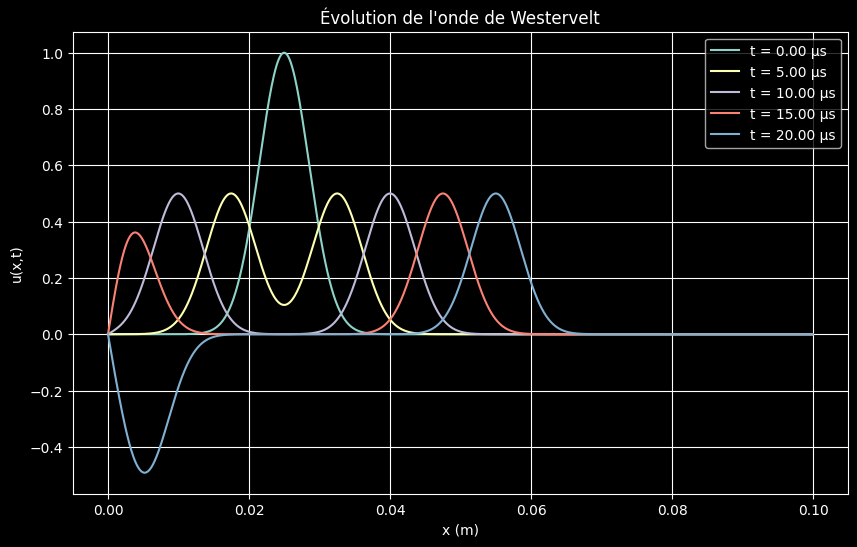

In [4]:
# Simulation avec Snapshots pour voir l'évolution
solver = WesterveltSolver(params)
solver.initialize(ic_type='gaussian')

times = [0, 5e-6, 1e-5, 1.5e-5, 2e-5]
snapshots = solver.run_with_snapshots(times)

solver.plot_snapshots(snapshots)


CFL condition: 0.300000
CFL condition: 0.300000


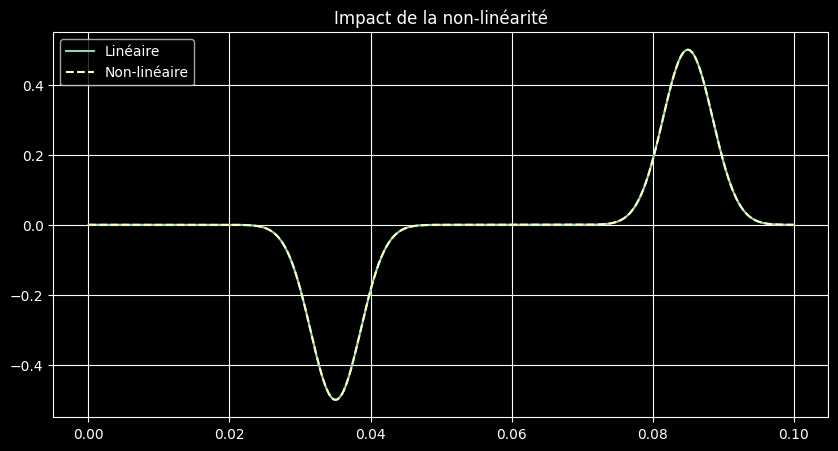

In [5]:
# Comparaison Linéaire vs Non-linéaire
params_lin = WesterveltParams(
    c=1500, epsilon=0.04, nu=1e-6, gamma=7, dx=1e-4, dt=2e-8, nx=1000, nt=2000, nonlinear=False
)

solver_lin = WesterveltSolver(params_lin)
solver_lin.initialize()
solver_lin.run()

solver_nonlin = WesterveltSolver(params)
solver_nonlin.initialize()
solver_nonlin.run()

plt.figure(figsize=(10, 5))
plt.plot(solver_lin.x, solver_lin.u, label='Linéaire')
plt.plot(solver_nonlin.x, solver_nonlin.u, '--', label='Non-linéaire')
plt.legend()
plt.title("Impact de la non-linéarité")
plt.grid(True)
plt.show()